In [ ]:
#KNN Imuter for missing values

#Univariate Imputation : We consider each feature individually and fill in the missing values in that feature only.
#Multivariate Imputation : We consider all the features and fill in the missing values in all the features at once. The data of the other features also affects the missing values of the present column

'''
    KNN Imputer Working : 
    1. Works on the K-Nearest Neighbors algorithm
    2. It calculates the values based on the nearest neighbours using distance metrics:
         - Euclidean distance: d = √[(x₁-y₁)² + (x₂-y₂)² + ... + (xₙ-yₙ)²]
         - Manhattan distance: d = |x₁-y₁| + |x₂-y₂| + ... + |xₙ-yₙ|
    
    3. Fills the present missing values with the nearest similar rows of the present column
    4. Distance calculation considers NaN Euclidean distance:
         - Only non-missing pairs contribute to distance calculation
         - Modified formula: d = √[∑(xᵢ-yᵢ)² for non-missing (xᵢ,yᵢ) pairs]
         - see the documentation of the sklearn regarding the na euclidean distance
         -see the video 39 campus x
    
    5. For k neighbors, imputed value is calculated as:
         Present_Missing_Value = (v₁ + v₂ + ... + vₖ)/k
         where v₁...vₖ are values from k nearest neighbors
    
    6. KNN Imputation is multivariate:
         - Uses information from all features
         - Considers relationships between variables
         - More accurate than univariate methods for correlated features
'''
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df=pd.read_csv('../Datasets/Titanic.csv')

df= df[['Age','Fare','Pclass','Survived']]
df.head()

#Splitting the data into train and test
x_train,x_test,y_train,y_test=train_test_split(df[['Age','Fare','Pclass']],df['Survived'],test_size=0.3,random_state=0)

imputer = KNNImputer(n_neighbors=5,weights='distance')

'''
    weights parameter determines how to calculate imputed values from neighbors:
    
    1. uniform: All points contribute equally
       - Example: For k=3 neighbors with values [10, 15, 20]
       - Missing_value = (10 + 15 + 20)/3 = 15
       
    2. distance: Points weighted by inverse distance
       - Example: For 3 neighbors:
         Values: [10, 15, 20]
         Distances: [2, 3, 4] 
         Weights = 1/distance = [1/2, 1/3, 1/4]
         Missing_value = (10*(1/2) + 15*(1/3) + 20*(1/4))/(1/2 + 1/3 + 1/4)
         = (5 + 5 + 5)/(0.5 + 0.33 + 0.25)
         ≈ 13.89
         
       - Closer neighbors have more influence
       - More robust to outliers
'''

x_train_trf=imputer.fit_transform(x_train)
x_test_trf = imputer.transform(x_test)
pd.DataFrame(x_train_trf,columns=['Age','Fare','Pclass'])



,Age,Fare,Pclass
0,51.0,26.5500,1.0
1,49.0,76.7292,1.0
2,1.0,46.9000,3.0
3,54.0,77.2875,1.0
4,18.1,14.4583,3.0
...,...,...,...
618,39.0,83.1583,1.0
619,19.0,7.8542,3.0
620,29.5,7.7333,3.0
621,36.0,17.4000,3.0


> ### Knowing the optimum value of the K

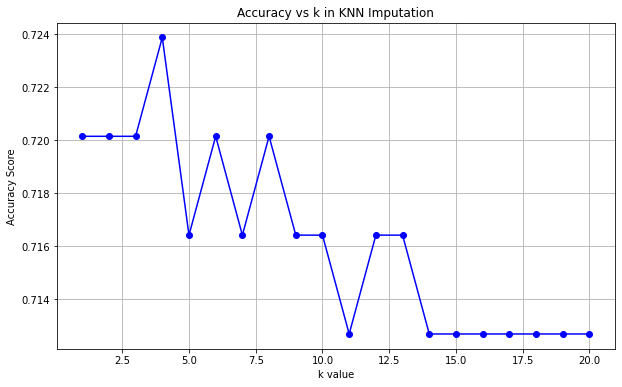

Optimal k value: 4
Best accuracy: 0.7239


In [8]:
# Let's find the optimal k by trying different values and comparing accuracy scores
k_values = range(1, 21)  # Testing k from 1 to 20
accuracy_scores = []

for k in k_values:
    imputer = KNNImputer(n_neighbors=k)
    x_train_imputed = imputer.fit_transform(x_train)
    x_test_imputed = imputer.transform(x_test)
    
    # Train logistic regression model
    model = LogisticRegression()
    model.fit(x_train_imputed, y_train)
    
    # Make predictions and calculate accuracy
    y_pred = model.predict(x_test_imputed)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Plot accuracy vs k values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, 'bo-')
plt.xlabel('k value')
plt.ylabel('Accuracy Score')
plt.title('Accuracy vs k in KNN Imputation')
plt.grid(True)
plt.show()

# Find optimal k
optimal_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f'Optimal k value: {optimal_k}')
print(f'Best accuracy: {max(accuracy_scores):.4f}')